   p             AIC             BIC
------------------------------------
   1      -26.117827      -26.087865
   2      -26.129069      -26.076616
   3      -26.147868      -26.072909
   4      -26.146712      -26.049230
   5      -26.153644      -26.033624
   6      -26.155405      -26.012829
   7      -26.174273      -26.009125
   8      -26.169267      -25.981532
   9      -26.165976      -25.955637
  10      -26.172525      -25.939565
  11      -26.174021      -25.918426
  12      -26.169789      -25.891540
  13      -26.164102      -25.863184
  14      -26.162300      -25.838696
  15      -26.161800      -25.815494
  16      -26.163972      -25.794948
  17      -26.160143      -25.768383
  18      -26.161522      -25.747011
  19      -26.167457      -25.730179
  20      -26.164709      -25.704647
  21      -26.168731      -25.685867
  22      -26.182035      -25.676354
  23      -26.178055      -25.649539
  24      -26.184667      -25.633301
  25      -26.179365      -25.605132
 

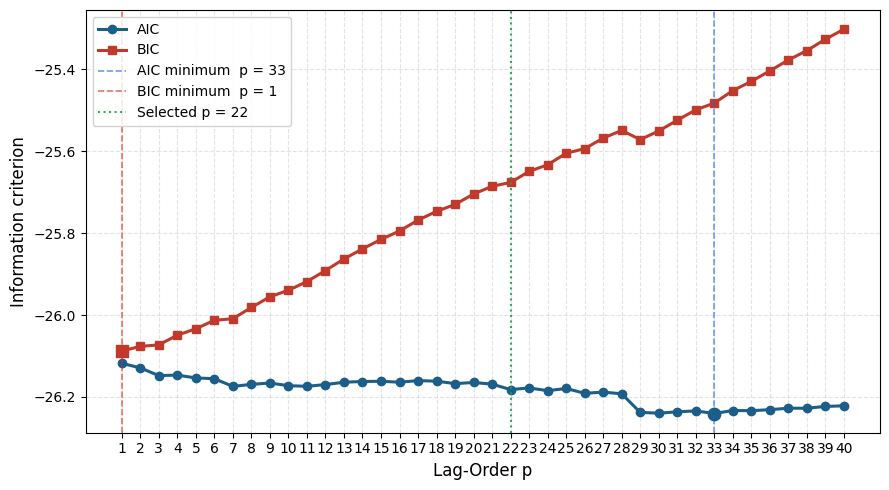

In [ ]:
# =========================================================================
# PURPOSE 
#   Perform lag-order selection for a Vector Autoregression (VAR) model.
#   The script estimates a VAR(p) by OLS for every p in {1, ..., p_max}
#   and records the Akaike Information Criterion (AIC) and the Bayesian /
#   Schwarz Information Criterion (BIC). The optimal lag length under
#   each criterion is the one that minimises the corresponding curve.
#
#   For a VAR(p)
#       y_t = mu + A_1 y_{t-1} + ... + A_p y_{t-p} + e_t,
#                  e_t ~ (0, Sigma)
#   the information criteria penalise the in-sample log-likelihood by the
#   number of estimated parameters:
#
#       AIC(p) = log|Sigma_hat(p)| + 2/T  * k(p),
#       BIC(p) = log|Sigma_hat(p)| + log(T)/T * k(p),
#
#   with k(p) the number of free parameters and T the effective sample
#   size. The script also marks a manually selected lag (`p_selected`)
#   that is used for the final structural model in the thesis, even if
#   it is not the strict minimiser of either curve.
#
#   External dependencies:
#       - Data.xlsx (input data, sheet 'Tabelle1')
# =========================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR

# -------------------------------------------------------------------------
# Load the data
# The file contains the columns Supply, Demand and Risk shocks at the
# daily frequency. Statsmodels' VAR class expects a wide pandas
# DataFrame with one column per endogenous variable.
# -------------------------------------------------------------------------
df = pd.read_excel(
    '/Users/johannesfelchner/Desktop/Code/Section 3/Section 3.2/Selection-p/Data.xlsx',
    sheet_name="Tabelle1",
    header=0,
)

# -------------------------------------------------------------------------
# Information criteria over the lag spectrum p = 1, ..., p_max
# `model.fit(maxlags=p, ic=None)` forces statsmodels to estimate the
# VAR with exactly p lags rather than letting it pick its own.
# -------------------------------------------------------------------------
p_max = 40
model = VAR(df)

aic_values = []
bic_values = []
p_values   = list(range(1, p_max + 1))

print(f"{'p':>4}  {'AIC':>14}  {'BIC':>14}")
print("-" * 36)

for p in p_values:
    result = model.fit(maxlags=p, ic=None)
    aic_values.append(result.aic)
    bic_values.append(result.bic)
    print(f"{p:>4}  {result.aic:>14.6f}  {result.bic:>14.6f}")

# -------------------------------------------------------------------------
# Argmin of each criterion
# -------------------------------------------------------------------------
p_aic = p_values[np.argmin(aic_values)]
p_bic = p_values[np.argmin(bic_values)]

# -------------------------------------------------------------------------
# Visualisation: AIC and BIC versus lag order p
# -------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 5))

# The two information-criterion curves.
ax.plot(p_values, aic_values, marker="o", linewidth=2.2,
        color="#1B5E8A", label="AIC")
ax.plot(p_values, bic_values, marker="s", linewidth=2.2,
        color="#C0392B", label="BIC")

# Dashed vertical lines at the data-driven minima.
ax.axvline(p_aic, color="#2563EB", linestyle="--", linewidth=1.2, alpha=0.65,
           label=f"AIC minimum  p = {p_aic}")
ax.axvline(p_bic, color="#DC2626", linestyle="--", linewidth=1.2, alpha=0.65,
           label=f"BIC minimum  p = {p_bic}")

# Manually chosen lag length used for the structural VAR estimation
# in the thesis (kept fixed across runs for reproducibility).
p_selected = 22
ax.axvline(p_selected, color="#16A34A", linestyle=":", linewidth=1.5, alpha=0.9,
           label=f"Selected p = {p_selected}")

# Highlight the actual minimum points so they pop out from the curves.
ax.scatter([p_aic], [min(aic_values)], color="#1B5E8A", zorder=5, s=80)
ax.scatter([p_bic], [min(bic_values)], color="#C0392B", zorder=5, s=80,
           marker="s")

# Cosmetic finishing touches.
ax.set_xlabel("Lag-Order p", fontsize=12)
ax.set_ylabel("Information criterion", fontsize=12)
ax.set_xticks(p_values)
ax.legend(fontsize=10, framealpha=0.85)
ax.grid(True, linestyle="--", alpha=0.35)

plt.tight_layout()